In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/processed/diabetic_data_cleaned.csv')
df.shape

(71518, 52)

In [2]:
#Does age predict readmission risk?
age_readmission = df.groupby('age')['readmitted_30d'].mean().sort_index()
age_readmission

age
[0-10)      0.019481
[10-20)     0.048598
[20-30)     0.073647
[30-40)     0.069655
[40-50)     0.073713
[50-60)     0.070512
[60-70)     0.088596
[70-80)     0.100165
[80-90)     0.103633
[90-100)    0.088421
Name: readmitted_30d, dtype: float64

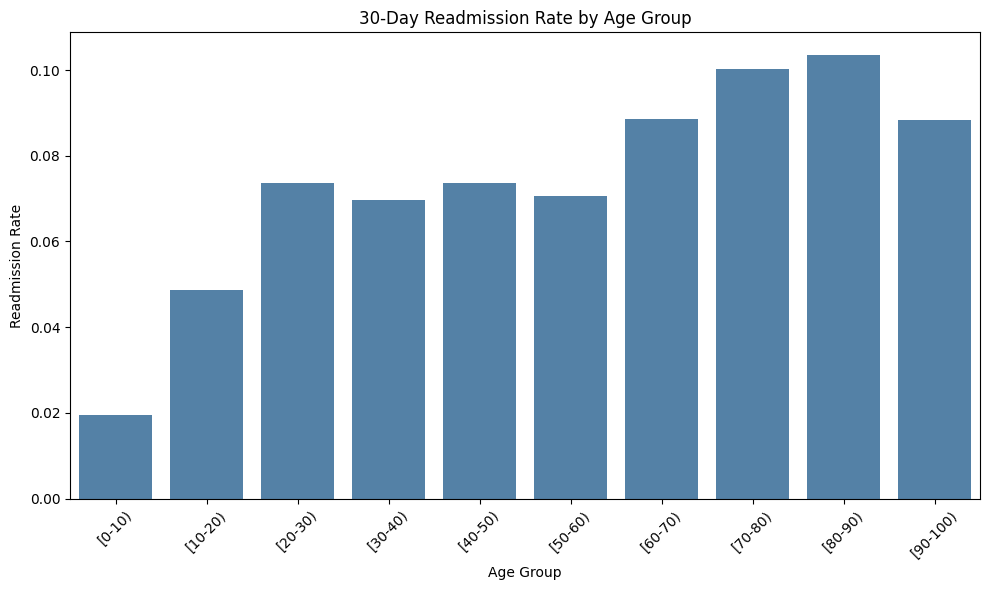

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(x=age_readmission.index, y=age_readmission.values, color='steelblue')
plt.title('30-Day Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../dashboard/age_readmission.png', dpi=150)
plt.show()

In [4]:
#Does primary diagnosis matter?
diag_readmission = df.groupby('diag_1_group')['readmitted_30d'].mean().sort_values(ascending=False)
diag_readmission

diag_1_group
Unknown            0.181818
Injury             0.105880
Circulatory        0.094866
Diabetes           0.090439
Genitourinary      0.088503
Other              0.088038
Neoplasms          0.084245
Musculoskeletal    0.083578
Digestive          0.079452
Respiratory        0.070683
Name: readmitted_30d, dtype: float64

In [5]:
prior_visits_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']
df[prior_visits_cols].describe()

,number_outpatient,number_emergency,number_inpatient
count,71518.000000,71518.000000,71518.000000
mean,0.280069,0.103540,0.177829
std,1.068957,0.509187,0.603790
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,42.000000,42.000000,12.000000


In [6]:
df.groupby('number_inpatient')['readmitted_30d'].mean()

number_inpatient
0     0.079665
1     0.125461
2     0.180995
3     0.226994
4     0.233051
5     0.284314
6     0.410714
7     0.473684
8     0.230769
9     0.375000
10    0.800000
11    0.500000
12    1.000000
Name: readmitted_30d, dtype: float64